In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file_path = "./bank+marketing/bank-additional-full.csv"
df = pd.read_csv(file_path, sep=";")
df['conversion'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,conversion
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [3]:
# Conversion

print(f"Total customers: {df.shape[0]}, Conversions: {df['conversion'].sum()}, Conversion Rate: {(df['conversion'].sum()/df.shape[0]):.2%}")

Total customers: 41188, Conversions: 4640, Conversion Rate: 11.27%


In [4]:
# Conversion by Age

conversions_by_age = 100*df.groupby(by='age')['conversion'].sum()/df.groupby(by='age')['conversion'].count()

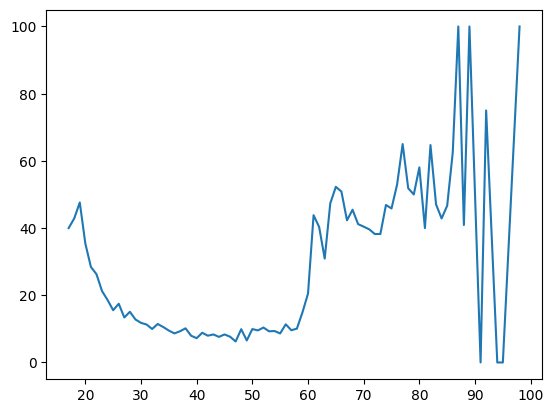

In [5]:
plt.plot(conversions_by_age);

In [6]:
# bucketing ages

df['age_group'] = df['age'].apply(lambda x: '[18,30)' if x < 30 \
                                  else '[30,40)' if x < 40 \
                                    else '[40,50)' if x < 50 \
                                        else '50+')

df[['age', 'age_group']].value_counts()

age  age_group
31   [30,40)      1947
32   [30,40)      1846
33   [30,40)      1833
36   [30,40)      1780
35   [30,40)      1759
                  ... 
98   50+             2
89   50+             2
95   50+             1
87   50+             1
94   50+             1
Name: count, Length: 78, dtype: int64

In [7]:
conversions_by_age_group = (df.groupby(by='age_group')['conversion'].sum()/df.groupby(by='age_group')['conversion'].count())
print(f"Conversion by age group: {100*conversions_by_age_group}")

Conversion by age group: age_group
50+        14.512725
[18,30)    16.263891
[30,40)    10.125162
[40,50)     7.923238
Name: conversion, dtype: float64


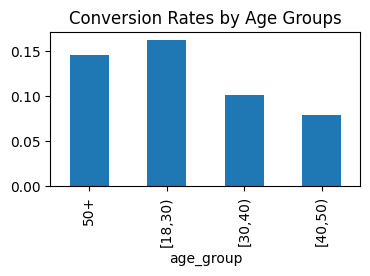

In [8]:
conversions_by_age_group.plot(kind='bar',
                              title="Conversion Rates by Age Groups",
                              figsize=(4,2));

In [9]:
# Converted vs Non Converted: on marital status

conversions_by_marital_status_df = pd.pivot_table(df, 
               values='y',
               index='marital',
               columns='conversion',
               aggfunc=len)

conversions_by_marital_status_df

conversion,0,1
marital,,
divorced,4136,476
married,22396,2532
single,9948,1620
unknown,68,12


array([<Axes: >, <Axes: >], dtype=object)

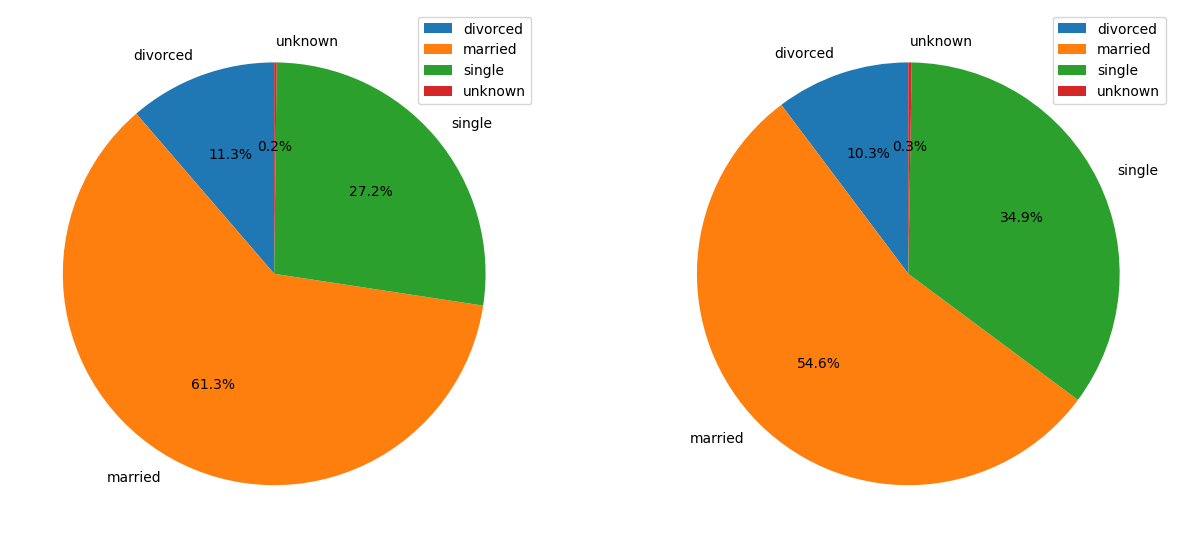

In [10]:
conversions_by_marital_status_df.plot(kind='pie',
                                      subplots=True,
                                      figsize=(15,7),
                                      startangle=90,
                                      autopct=lambda x: f"{x/100:.1%}")

In [20]:
age_marital_df = df.groupby(['age_group', 'marital'])['conversion'].sum().unstack('marital').fillna(0)
age_marital_df = 100*age_marital_df.divide(
    df.groupby(by='age_group')['conversion'].count(),
    axis=0
)

<Axes: xlabel='age_group'>

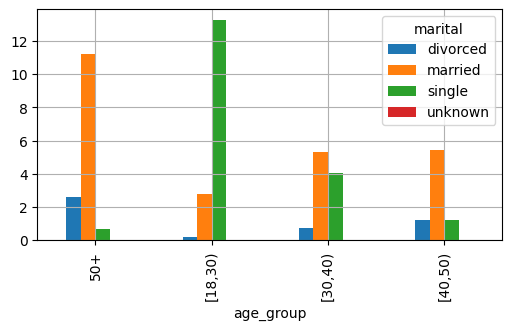

In [21]:
age_marital_df.plot(kind="bar",
                    grid=True,
                    figsize=(6,3))

<Axes: xlabel='age_group'>

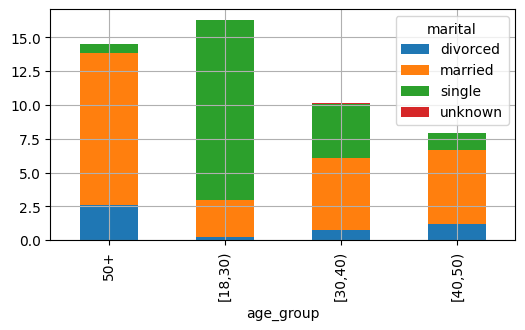

In [22]:
age_marital_df.plot(kind="bar",
                    grid=True,
                    stacked=True,
                    figsize=(6,3))